# 04 — 2D Molecular Graph (GINEConv) — standalone ablation

`SMILES -> RDKit mol -> PyG graph (atom+bond features) -> GINEConv x4 -> mean+max pool -> classifier`.
This is the **2D-only** row in the ablation table. Independent of notebooks 2/3 — same `splits.json`,
same shared `train_binary_classifier`.


In [1]:
import sys
sys.path.append("..")

from pathlib import Path

import yaml
import torch
from torch_geometric.loader import DataLoader

from src.utils import load_json, save_json, set_seed
from src.graph_featurizer import mol_to_graph_data, ATOM_FEAT_DIM, BOND_FEAT_DIM
from src.models import Graph2DModel
from src.train_utils import train_binary_classifier, evaluate

with open("../config/model_2d.yaml") as f:
    cfg = yaml.safe_load(f)

set_seed(cfg["train"]["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print(f"atom_feat_dim={ATOM_FEAT_DIM}  bond_feat_dim={BOND_FEAT_DIM}")


c:\Users\ajaya\anaconda3\envs\chemprop\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


device: cuda
atom_feat_dim=43  bond_feat_dim=11


## Build graphs

Same `splits.json` as notebook 3 (already filtered for the 4 ETKDG failures).

In [2]:
splits = load_json(cfg["paths"]["splits_file"])

graph_datasets = {}
for split_name in ["train", "valid", "test"]:
    data_list = [
        mol_to_graph_data(smi, label)
        for smi, label in zip(splits[split_name]["smiles"], splits[split_name]["y"])
    ]
    failed = sum(d is None for d in data_list)
    if failed:
        print(f"WARNING: {failed} SMILES failed graph featurization in {split_name}")
    graph_datasets[split_name] = [d for d in data_list if d is not None]

print({k: len(v) for k, v in graph_datasets.items()})


[11:04:24] WARNING: not removing hydrogen atom without neighbors


{'train': 453, 'valid': 66, 'test': 132}


[11:04:24] WARNING: not removing hydrogen atom without neighbors


In [3]:
loaders = {
    "train": DataLoader(graph_datasets["train"], batch_size=cfg["train"]["batch_size"], shuffle=True),
    "valid": DataLoader(graph_datasets["valid"], batch_size=cfg["train"]["batch_size"], shuffle=False),
    "test":  DataLoader(graph_datasets["test"],  batch_size=cfg["train"]["batch_size"], shuffle=False),
}

batch = next(iter(loaders["train"]))
print(batch)


DataBatch(x=[827, 43], edge_index=[2, 1770], edge_attr=[1770, 11], label=[32], batch=[827], ptr=[33])


## Model, forward_fn, train

In [4]:
model = Graph2DModel(
    atom_feat_dim=ATOM_FEAT_DIM, bond_feat_dim=BOND_FEAT_DIM,
    hidden_dim=cfg["model"]["hidden_dim"], n_layers=cfg["model"]["n_layers"], dropout=cfg["model"]["dropout"],
)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model params: {n_params:,}")

def forward_fn(model, batch, device):
    batch = batch.to(device)
    return model(batch.x, batch.edge_index, batch.edge_attr, batch.batch)


Model params: 161,409


In [5]:
model, train_info = train_binary_classifier(
    model, loaders["train"], loaders["valid"], forward_fn, cfg, cfg["paths"]["experiment_dir"], device
)
train_info


c:\Users\ajaya\anaconda3\envs\chemprop\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


epoch   1  train_loss=0.6311  val_loss=0.6509  val_auroc=0.5150


c:\Users\ajaya\anaconda3\envs\chemprop\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


epoch   2  train_loss=0.5381  val_loss=0.6022  val_auroc=0.5800


c:\Users\ajaya\anaconda3\envs\chemprop\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


...

c:\Users\ajaya\anaconda3\envs\chemprop\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


epoch  16  train_loss=0.3284  val_loss=0.3779  val_auroc=0.8513


c:\Users\ajaya\anaconda3\envs\chemprop\Lib\site-packages\torch_geometric\utils\_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


epoch  17  train_loss=0.3111  val_loss=0.4066  val_auroc=0.8150
Early stopping at epoch 17 (no val AUROC improvement for 10 epochs)


{'best_val_auroc': 0.88125, 'epochs_trained': 17}

In [6]:
val_metrics = evaluate(model, loaders["valid"], forward_fn, device)
print(f"2D-only val AUROC: {val_metrics['auroc']:.4f}")

save_json(
    {"model": "2d_only", **val_metrics, **train_info, "config": cfg},
    Path(cfg["paths"]["experiment_dir"]) / "metrics.json",
)


2D-only val AUROC: 0.8812


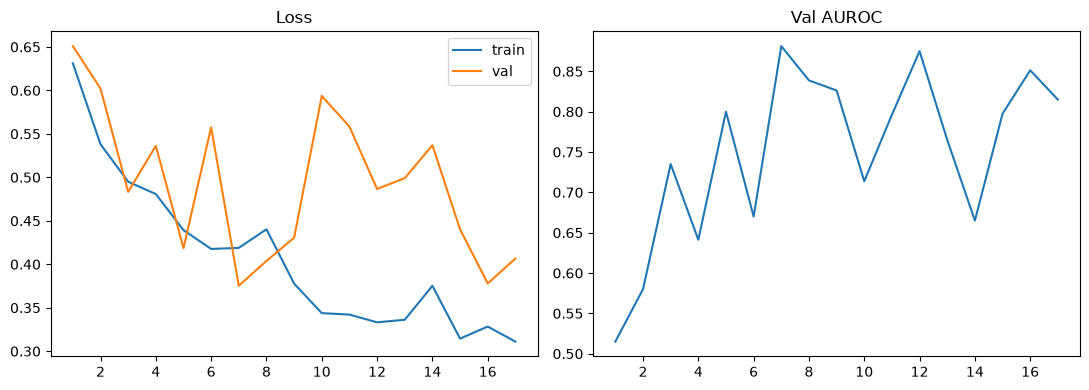

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

log = pd.read_csv(Path(cfg["paths"]["experiment_dir"]) / "train_log.csv")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(log["epoch"], log["train_loss"], label="train")
axes[0].plot(log["epoch"], log["val_loss"], label="val")
axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(log["epoch"], log["val_auroc"])
axes[1].set_title("Val AUROC")
plt.tight_layout()
plt.show()


## Compare against 1D so far

In [8]:
d1 = load_json("../experiments/1d_only/metrics.json")
d2 = load_json("../experiments/2d_only/metrics.json")
print(f"1D-only val AUROC: {d1['auroc']:.4f}")
print(f"2D-only val AUROC: {d2['auroc']:.4f}")


1D-only val AUROC: 0.8462
2D-only val AUROC: 0.8812
